# Preparando os Dados (1)

In [101]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

features = pd.read_csv('sonar_dataset.csv')

target = features.iloc[:, -1]
target.replace({'M': 0, 'R': 1}, inplace = True)

features = features.iloc[:, :-1]
pca_vetor = {}
print("Matriz:", features.shape)

Matriz: (207, 60)


/tmp/ipython-input-948033466.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target.replace({'M': 0, 'R': 1}, inplace = True)


#PCA com Arvore de Decisão com Cross Validation e Grid Search (2-5)

In [102]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

#fazendo o treinamento com diferentes quantidades de componentes

for comp in range(5, 40, 5):
  pca = PCA(whiten = False, n_components = comp)
  pca.fit(features)
  pca_feat = pca.transform(features)
  pca_feat = StandardScaler().fit_transform(pca_feat)

  arvore = DecisionTreeClassifier();
  param_grid = {"criterion": ["gini", "entropy", "log_loss"],
                "max_depth": list(range(5, 250, 20)),
                "min_samples_split": list(range(1, 10, 2)),
                "min_samples_leaf": list(range(1, 10, 2))
                }
  grid = GridSearchCV(estimator = arvore, param_grid = param_grid, cv = 5).fit(pca_feat, target)
  pca_vetor[comp] = {
      "score": grid.best_score_,
      "param": grid.best_params_,
      "model": grid.best_estimator_
  }

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
975 fits failed out of a total of 4875.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
975 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/uti

# Avaliação dos Modelos (6)


 15 Componentes
Acuracia: 99.51690821256038 %

Parametros: {'criterion': 'log_loss', 'max_depth': 105, 'min_samples_leaf': 1, 'min_samples_split': 5}
F1 score: 0.9948186528497409
Precisão: 0.9896907216494846
Recall: 1.0


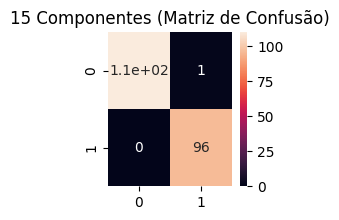

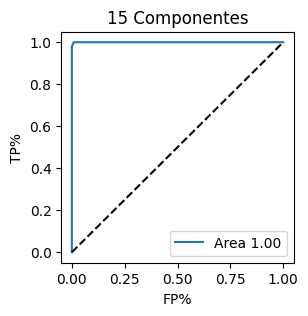


 10 Componentes
Acuracia: 94.68599033816425 %

Parametros: {'criterion': 'entropy', 'max_depth': 125, 'min_samples_leaf': 3, 'min_samples_split': 3}
F1 score: 0.9411764705882353
Precisão: 0.967032967032967
Recall: 0.9166666666666666


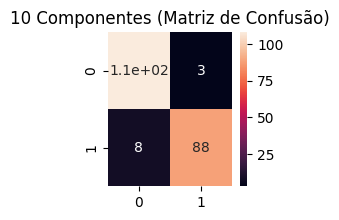

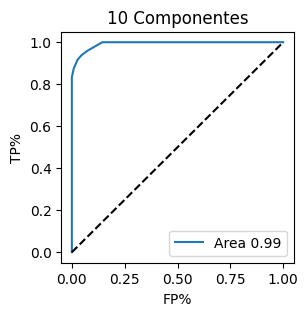


 20 Componentes
Acuracia: 95.16908212560386 %

Parametros: {'criterion': 'gini', 'max_depth': 45, 'min_samples_leaf': 3, 'min_samples_split': 5}
F1 score: 0.9494949494949495
Precisão: 0.9215686274509803
Recall: 0.9791666666666666


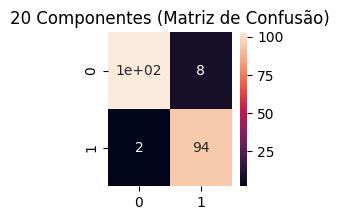

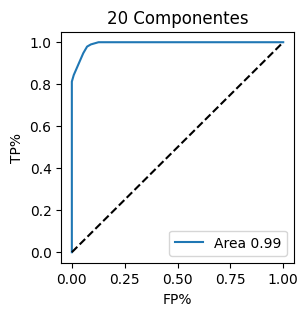


 25 Componentes
Acuracia: 94.68599033816425 %

Parametros: {'criterion': 'gini', 'max_depth': 45, 'min_samples_leaf': 3, 'min_samples_split': 7}
F1 score: 0.9424083769633508
Precisão: 0.9473684210526315
Recall: 0.9375


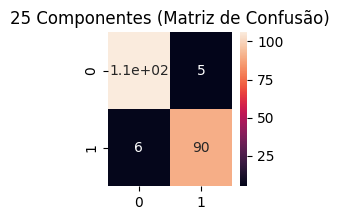

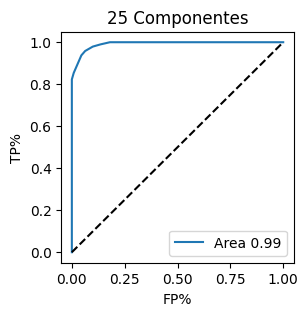


 30 Componentes
Acuracia: 94.68599033816425 %

Parametros: {'criterion': 'gini', 'max_depth': 85, 'min_samples_leaf': 3, 'min_samples_split': 9}
F1 score: 0.9430051813471503
Precisão: 0.9381443298969072
Recall: 0.9479166666666666


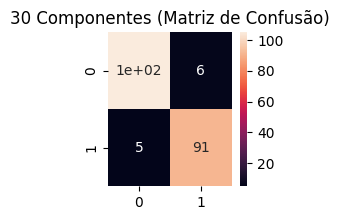

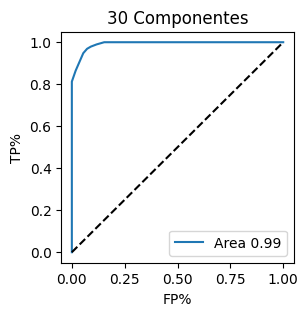


 35 Componentes
Acuracia: 94.68599033816425 %

Parametros: {'criterion': 'entropy', 'max_depth': 45, 'min_samples_leaf': 3, 'min_samples_split': 9}
F1 score: 0.9430051813471503
Precisão: 0.9381443298969072
Recall: 0.9479166666666666


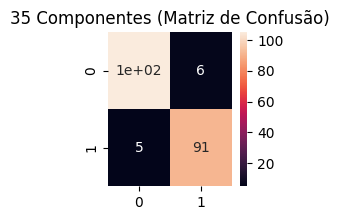

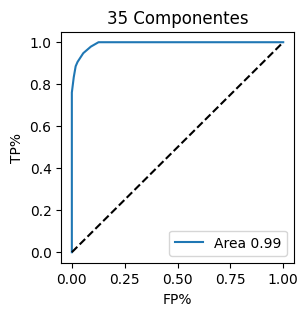


 5 Componentes
Acuracia: 87.43961352657004 %

Parametros: {'criterion': 'log_loss', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 5}
F1 score: 0.8586956521739131
Precisão: 0.8977272727272727
Recall: 0.8229166666666666


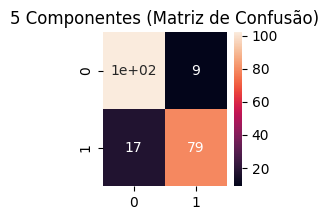

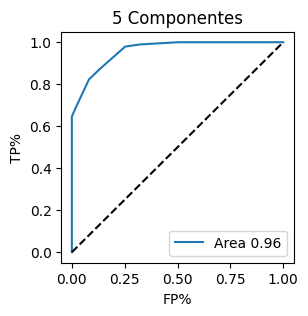

In [122]:
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, precision_score, recall_score, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

#ordenando por acuracia do melhor modelo de cada N componentes

for comp_i in sorted(pca_vetor, key=lambda x: pca_vetor[x]["score"], reverse=True):
  model = pca_vetor[comp_i]["model"]

  pca = PCA(whiten = False, n_components = comp_i)
  pca.fit(features)
  pca_feat = pca.transform(features)
  pca_feat = StandardScaler().fit_transform(pca_feat)

  y_pred = model.predict(pca_feat)
  y_prob = model.predict_proba(pca_feat)[:, 1]

  print("\n", comp_i, "Componentes")
  print("Acuracia:", accuracy_score(target, y_pred)*100, "%\n")
  print("Parametros:", pca_vetor[comp_i]["param"])

  print("F1 score:", f1_score(target, y_pred))
  print("Precisão:", precision_score(target, y_pred))
  print("Recall:", recall_score(target, y_pred))

  cm = confusion_matrix(target, y_pred)
  plt.figure(figsize = (2,2))
  plt.xlabel('Predito')
  plt.ylabel('Verdadeiro')
  plt.title(f'{comp_i} Componentes (Matriz de Confusão)')
  sns.heatmap(cm, annot=True)


  fpr, tpr, thresholds = roc_curve(target, y_prob)
  plt.figure(figsize = (3,3))
  plt.plot(fpr, tpr, label='Area %0.2f' % roc_auc_score(target, y_prob))
  plt.plot([0, 1], [0, 1], 'k--')
  plt.xlabel('FP%')
  plt.ylabel('TP%')
  plt.title(f'{comp_i} Componentes')
  plt.legend(loc="lower right")
  plt.show()

# Conclusão

Com os seguintes parametros para o PCA e a arvore de decisão:<br>

*   15 Componentes<br>
*   Parametros: {'criterion': 'log_loss', 'max_depth': 105, 'min_samples_leaf': 1, 'min_samples_split': 5}

Obtemos um EXCELENTE resultado para as principais métricas de classificação:<br>
*   Acuracia: 99.51%<br>
*   F1 score: 99.48%<br>
*   Precisão: 98.96%<br>
*   Recall: 100%<br>

Ou seja, ele vai praticamente acertar sempre se uma leitura for de uma mina terrestre ou rocha, provavelmente devido a diferença material drastica entre rochas e massas compactas de ferro industrializado (minas).